**Libraries Import**

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Load Karna**

In [86]:
df = pd.read_csv("Advertising.csv")

In [87]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [110]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Null Values Check**

In [88]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


**Extra Column Remove**

In [89]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

In [90]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


**CORRELATION HEATMAP**

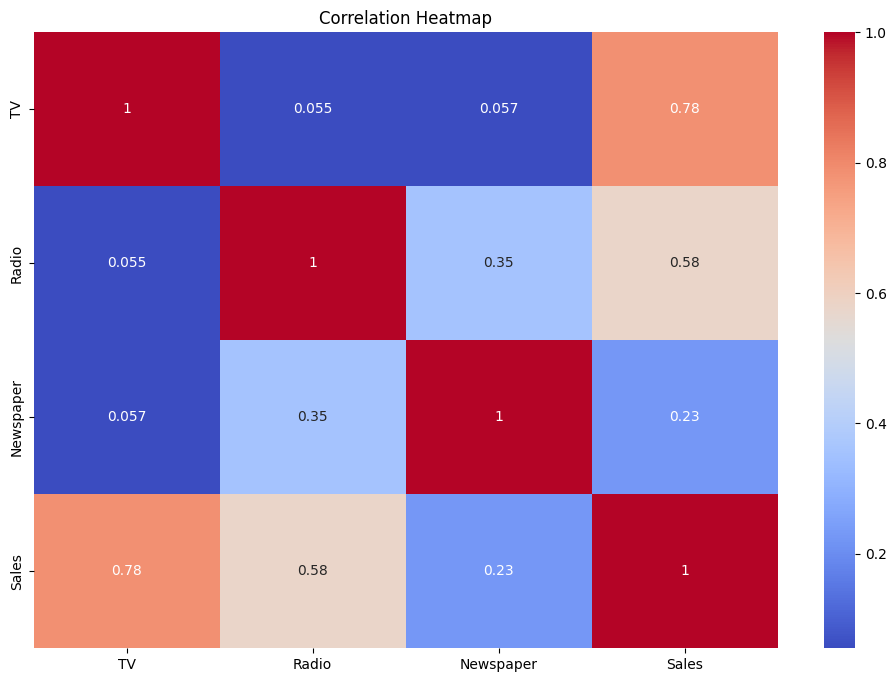

In [111]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**TV Advertising vs Sales**

<Axes: xlabel='TV', ylabel='Sales'>

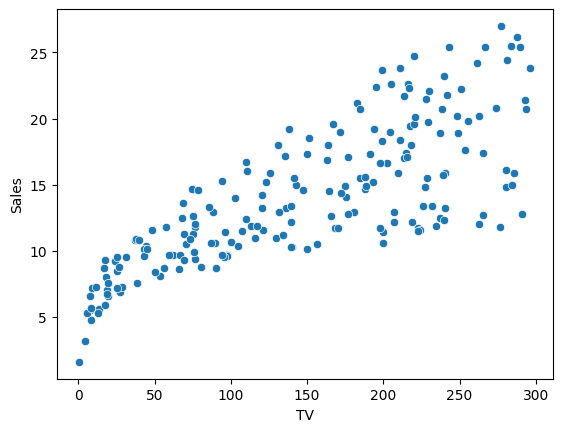

In [112]:
sns.scatterplot(x=df['TV'], y=df['Sales'])

**Features Aur Target Select Karna**

In [91]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

**Train Test Split**

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Train**

In [94]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Prediction**

In [95]:
y_pred = model.predict(X_test)

**Accuracy Check**

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [97]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.6307899999999875


In [98]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5626169039999962


In [99]:
print(r2_score(y_test, y_pred))

0.9821751316261319


**Check Model on Random Data**

In [108]:
new_data = pd.DataFrame({
    'TV': [44.5],
    'Radio': [39.3],
    'Newspaper': [45.1]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 10.694199999999885
